# 1. Conhecendo a Base de Dados

Dataset para Prever o Valor de um Seguro de Saúde

* Idade

* Sexo Biológico

* IMC - índice de massa corporal

* Fumante

* Children - quantos filhos possuem

* Região que reside

* Valor do Seguro

In [1]:
# Importando os dados e visualizando as 5 primeiras linhas
import pandas as pd
import numpy as np

dados = pd.read_csv('/content/insurance.csv')
dados.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


* Fazendo a Tradução das colunas para um melhor entendimento dos dados

In [2]:
dados.columns = ['idade', 'sexo', 'imc', 'filhos', 'fumante', 'regiao', 'valor_seguro']
dados.head()

,idade,sexo,imc,filhos,fumante,regiao,valor_seguro
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Análises Preliminares

Nesta etapa realizamos uma exploração inicial do dataset para compreender sua estrutura e qualidade antes da construção do modelo de Machine Learning.

Primeiramente analisamos a estrutura dos dados, identificando a quantidade de registros, colunas e os tipos de variáveis presentes no conjunto de dados.

Em seguida, verificamos os valores únicos das variáveis categóricas (`sexo`, `fumante` e `regiao`) para entender quais categorias existem no dataset.

Também realizamos a verificação de valores nulos e registros duplicados, garantindo a consistência e integridade dos dados utilizados no modelo.

Por fim, foi feita uma análise estatística descritiva das variáveis numéricas, observando métricas como média, desvio padrão, valores mínimos, máximos e quartis para entender melhor a distribuição dos dados.

* Verificando os tipos dos dados , suas quantidades e se possuem dados nulos

In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   idade         1338 non-null   int64  
 1   sexo          1338 non-null   object 
 2   imc           1338 non-null   float64
 3   filhos        1338 non-null   int64  
 4   fumante       1338 non-null   object 
 5   regiao        1338 non-null   object 
 6   valor_seguro  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


* Verificando quais dados temos dentro das colunas de texto no dataset - pegando seus valores únicos

In [4]:
print(f'Sexo : {dados.sexo.unique()}')
print(f'Fumante : {dados.fumante.unique()}')
print(f'Região : {dados.regiao.unique()}')

Sexo : ['female' 'male']
Fumante : ['yes' 'no']
Região : ['southwest' 'southeast' 'northwest' 'northeast']


* Verificando dados nulos do dataset

In [5]:
print(f'Total de dados nulos : {dados.isnull().sum().sum()}')

Total de dados nulos : 0


* Verificando os dados duplicados do dataset

In [6]:
print(f'Total de dados duplicados : {dados.duplicated().sum()}')

Total de dados duplicados : 1


In [7]:
dados = dados.drop_duplicates()
print(f'Total de dados duplicados : {dados.duplicated().sum()}')

Total de dados duplicados : 0


* Pegando a Estatística Descritiva do Dataset

In [8]:
dados.describe().round(2)

,idade,imc,filhos,valor_seguro
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


# 2. Análises Gráficas

## Comportamento da Variável Dependente (Y)

Nesta etapa analisamos o comportamento da variável alvo `valor_seguro`, que representa o valor do seguro e será a variável a ser prevista pelo modelo.

Inicialmente utilizamos um **boxplot** para visualizar a distribuição dos valores e identificar possíveis outliers presentes no dataset.

Em seguida, analisamos as **estatísticas descritivas** da variável, observando métricas como média, desvio padrão, quartis e valores extremos, o que ajuda a entender melhor a escala e a variação dos valores.

Por fim, utilizamos um **histograma com KDE** para visualizar a distribuição dos dados. A análise mostra uma distribuição assimétrica à direita (right-skewed), indicando a presença de valores elevados que podem impactar o desempenho do modelo.

Diante desse comportamento, pode ser necessária a aplicação de uma **transformação logarítmica** na variável alvo para reduzir a assimetria e melhorar o aprendizado do modelo.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Accent')
sns.set_theme(style='darkgrid')

* Verificando com o BOXPLOT se os valores do Seguro estão bem distribuídos e se apresentam Outliers

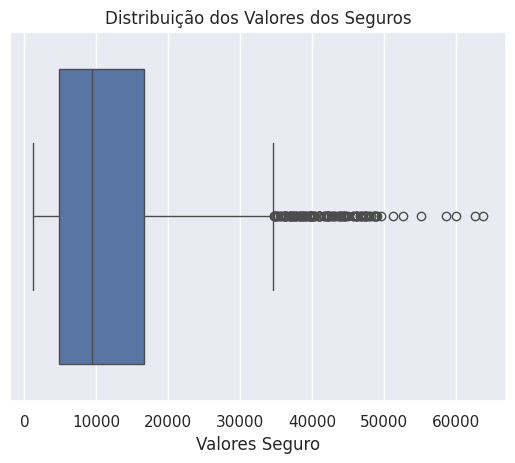

In [10]:
sns.boxplot(data=dados, x='valor_seguro')
plt.title('Distribuição dos Valores dos Seguros')
plt.xlabel('Valores Seguro')
plt.show()

In [11]:
dados['valor_seguro'].describe().round(2)

,valor_seguro
count,1337.00
mean,13279.12
std,12110.36
min,1121.87
25%,4746.34
50%,9386.16
75%,16657.72
max,63770.43


* Verificando agora a DISTRIBUIÇÃO dos dados, e notamos que precisa ser feita transformação logarítmica para ajustar os valores

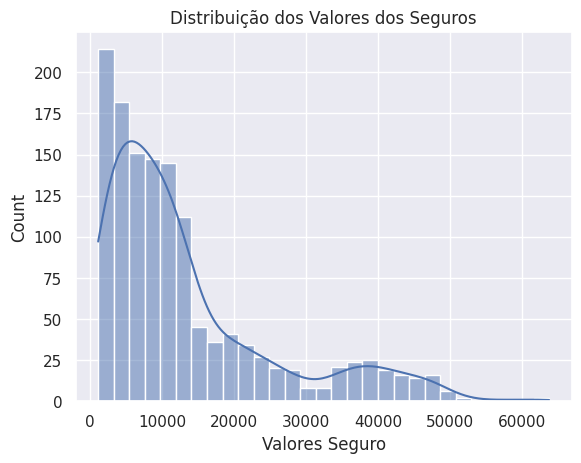

In [12]:
sns.histplot(data=dados, x='valor_seguro', kde=True)
plt.title('Distribuição dos Valores dos Seguros')
plt.xlabel('Valores Seguro')
plt.show()

* Nota-se que os dados dos valores do Seguro estão de forma assimétrica

## Pegando a Correlação dos Dados e Dispersão entre as Variáveis

Nesta etapa analisamos a correlação entre as variáveis numéricas do dataset com o objetivo de identificar possíveis relações entre elas e com a variável alvo.

Primeiramente calculamos a **matriz de correlação**, considerando apenas as variáveis numéricas. Em seguida, utilizamos um **heatmap** para visualizar a intensidade dessas correlações, facilitando a identificação de relações positivas ou negativas entre as variáveis.

Posteriormente, analisamos a **dispersão das variáveis independentes em relação à variável alvo (`valor_seguro`)** utilizando gráficos de dispersão com linha de regressão. Essa visualização permite observar possíveis tendências e relações lineares entre as variáveis `idade`, `imc` e `filhos` com o valor do seguro.

Essa análise ajuda a entender quais variáveis podem ter maior influência na previsão do valor do seguro e contribui para a interpretação do modelo.

In [13]:
# pegando a correlação apenas dos dados numéricos
correlacao = dados.select_dtypes(include=[np.number]).corr().round(2)

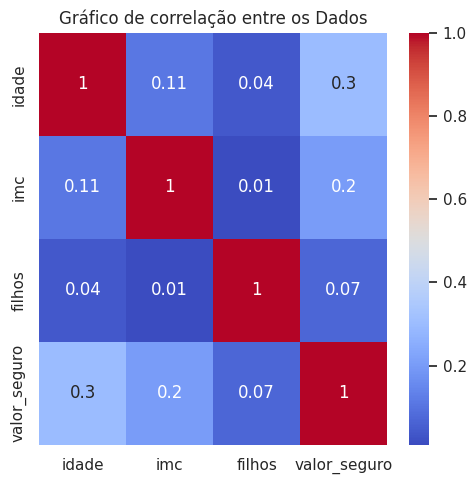

In [14]:
ax = plt.subplots(figsize=(5,5))
ax = sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Gráfico de correlação entre os Dados')
plt.tight_layout()
plt.show()

* Verificando a Dispersão das Variáveis em Relação a Valor do Seguro

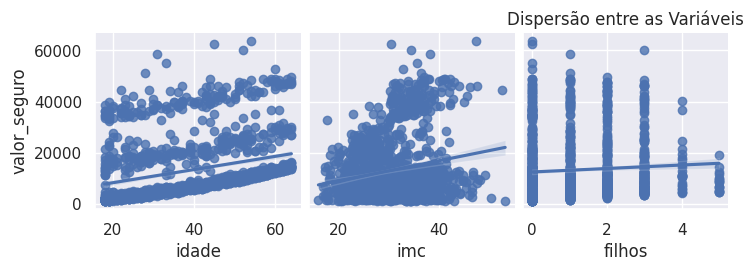

In [15]:
sns.pairplot(data=dados, y_vars='valor_seguro', x_vars=['idade','imc', 'filhos'], kind='reg')
plt.title('Dispersão entre as Variáveis')
plt.show()

## Divisão em X e Y

Nesta etapa, foi aplicada uma transformação logarítmica na variável alvo (`valor_seguro`) com o objetivo de reduzir a assimetria e melhorar o desempenho do modelo.

Em seguida, os dados foram separados em variáveis independentes (X) e variável dependente (y), onde X contém as características utilizadas na predição e y representa o valor do seguro de saúde.

In [16]:
dados['valor_seguro'] = np.log(dados['valor_seguro'])

In [17]:
X = dados.drop('valor_seguro', axis=1)
y = dados['valor_seguro']

# 3. Pré-processamento dos Dados

Nesta etapa realizamos o pré-processamento dos dados com o objetivo de preparar as variáveis para utilização nos modelos de Machine Learning.

Inicialmente identificamos os tipos de variáveis presentes no dataset, separando aquelas que receberão transformações específicas. As variáveis numéricas (`idade`, `imc` e `valor_seguro`) recebem **transformação logarítmica**, com o objetivo de reduzir a assimetria da distribuição e melhorar o comportamento dos dados para o modelo.

As variáveis categóricas binárias (`sexo` e `fumante`) são transformadas utilizando **One-Hot Encoding**, convertendo as categorias em representações numéricas.

Já a variável categórica multiclasse (`regiao`) também é transformada utilizando **One-Hot Encoding**, permitindo que o modelo interprete corretamente cada categoria.

Todas essas transformações são organizadas utilizando um **ColumnTransformer**, garantindo que cada tipo de variável receba o tratamento adequado dentro de um pipeline estruturado de pré-processamento.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer

In [19]:
dados.columns

Index(['idade', 'sexo', 'imc', 'filhos', 'fumante', 'regiao', 'valor_seguro'], dtype='object')

In [20]:
dados_log = ['idade', 'imc']
binarias = ['sexo', 'fumante']
multiclasse = ['regiao']

pipeline = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log), dados_log),
        ('bin', OneHotEncoder(drop='first'), binarias),
        ('multi', OneHotEncoder(drop='first'), multiclasse)
    ],
    remainder='passthrough'
)

In [21]:
dados_tratado = pipeline.fit_transform(X)

In [22]:
bin_cols = pipeline.named_transformers_['bin'].get_feature_names_out(binarias)
multi_cols = pipeline.named_transformers_['multi'].get_feature_names_out(multiclasse)

In [23]:
X_tratado = pd.DataFrame(dados_tratado, columns=list(dados_log) + list(bin_cols) + list(multi_cols) + ['filhos'])
X_tratado.head()

,idade,imc,sexo_male,fumante_yes,regiao_northwest,regiao_southeast,regiao_southwest,filhos
0,2.944439,3.328627,0.0,1.0,0.0,0.0,1.0,0.0
1,2.890372,3.519573,1.0,0.0,0.0,1.0,0.0,1.0
2,3.332205,3.496508,1.0,0.0,0.0,1.0,0.0,3.0
3,3.496508,3.122585,1.0,0.0,1.0,0.0,0.0,0.0
4,3.465736,3.363149,1.0,0.0,1.0,0.0,0.0,0.0


# 4. Separação dos Dados – Treino e Teste

Os dados são divididos em conjuntos de **treinamento** e **teste** utilizando a função `train_test_split` da biblioteca `scikit-learn`.

O conjunto de treino é utilizado para que o modelo aprenda os padrões presentes nos dados, enquanto o conjunto de teste é utilizado para avaliar o desempenho do modelo em dados que ele ainda não viu.

Foi definido que **80% dos dados** serão utilizados para treinamento e **20% para teste**, garantindo uma avaliação mais confiável da capacidade de generalização do modelo.

In [24]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(X_tratado, y, test_size=0.2, random_state=42)

# 5. Modelos De Machine Learning

## Regressão Linear com StatsModels

Nesta etapa aplicamos um modelo de **Regressão Linear** utilizando a biblioteca `StatsModels`, com o objetivo de analisar a relação entre as variáveis independentes e a variável alvo `valor_seguro`.

Inicialmente adicionamos uma **constante ao conjunto de variáveis preditoras**, permitindo que o modelo estime corretamente o intercepto da regressão.

Em seguida, o modelo é treinado utilizando o método **OLS (Ordinary Least Squares)**, que busca encontrar os coeficientes que minimizam a soma dos erros quadráticos entre os valores reais e os valores previstos.

Por fim, analisamos o **resumo estatístico do modelo**, que apresenta métricas importantes como R², coeficientes das variáveis, erros padrão e valores de significância, permitindo avaliar a qualidade do ajuste e a influência de cada variável no modelo.

In [25]:
import statsmodels.api as sm

In [26]:
x_treino = x_treino.reset_index(drop=True)
y_treino = y_treino.reset_index(drop=True)

In [27]:
x_treino_com_constante = sm.add_constant(x_treino)

modelo_statsmodels = sm.OLS(y_treino, x_treino_com_constante).fit()

In [28]:
print(modelo_statsmodels.summary())

                            OLS Regression Results                            
Dep. Variable:           valor_seguro   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     396.1
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          3.54e-312
Time:                        12:29:22   Log-Likelihood:                -672.38
No. Observations:                1069   AIC:                             1363.
Df Residuals:                    1060   BIC:                             1408.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.9201      0.262  

* regiao_northwest tem p-value = 0.253, ou seja, estatisticamente ela não parece contribuir muito

## Regressão Linear com Scikit-Learn

Nesta etapa implementamos um modelo de **Regressão Linear** utilizando a biblioteca `Scikit-Learn`, uma das ferramentas mais utilizadas em projetos de Machine Learning.

O modelo é treinado utilizando o conjunto de dados de **treinamento**, permitindo que o algoritmo aprenda a relação entre as variáveis independentes e a variável alvo `valor_seguro`.

Após o treinamento, avaliamos o desempenho do modelo utilizando métricas de regressão importantes:

- **R² (Coeficiente de Determinação):** indica o quanto da variação da variável alvo é explicada pelo modelo.
- **MAE (Mean Absolute Error):** representa o erro médio absoluto entre os valores reais e os valores previstos.
- **RMSE (Root Mean Squared Error):** mede a raiz do erro quadrático médio, penalizando erros maiores.

Essas métricas são calculadas tanto para o **conjunto de treino** quanto para o **conjunto de teste**, permitindo avaliar a capacidade de generalização do modelo.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [30]:
modelo_lr = LinearRegression()
modelo_lr.fit(x_treino, y_treino)

LinearRegression()

* Avaliando métricas - R², MAE, RMSE

In [31]:
print('Métricas Regressão Linear Treino:')
print(f'R²: {metrics.r2_score(y_treino, modelo_lr.predict(x_treino))}')
print(f'MAE: {metrics.mean_absolute_error(y_treino, modelo_lr.predict(x_treino))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_treino, modelo_lr.predict(x_treino)))}')


print('\nMétricas Regressão Linear Teste:')
print(f'R²: {metrics.r2_score(y_teste, modelo_lr.predict(x_teste))}')
print(f'MAE: {metrics.mean_absolute_error(y_teste, modelo_lr.predict(x_teste))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_teste, modelo_lr.predict(x_teste)))}')

Métricas Regressão Linear Treino:
R²: 0.7493291698944091
MAE: 0.2963517814991852
RMSE: 0.5443820179792727

Métricas Regressão Linear Teste:
R²: 0.8352703578222026
MAE: 0.2655266312434743
RMSE: 0.5152927626538862


## Random Forest

Nesta etapa utilizamos o algoritmo **Random Forest Regressor**, um modelo de ensemble baseado em múltiplas árvores de decisão.

O modelo é treinado utilizando o conjunto de **dados de treinamento**, onde cada árvore da floresta aprende padrões diferentes presentes nos dados. A previsão final é obtida a partir da combinação das previsões dessas árvores, o que tende a reduzir erros e melhorar a capacidade de generalização do modelo.

Para este experimento foi definido um limite de profundidade (`max_depth=10`) para as árvores, evitando que o modelo se torne excessivamente complexo e reduza o risco de overfitting.

Após o treinamento, o desempenho do modelo é avaliado utilizando as métricas **R², MAE e RMSE**, tanto no conjunto de **treino** quanto no conjunto de **teste**, permitindo comparar o desempenho da Random Forest com o modelo de regressão linear.

In [32]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
modelo_rf = RandomForestRegressor(max_depth=10, random_state=42)
modelo_rf.fit(x_treino, y_treino)

RandomForestRegressor(max_depth=10, random_state=42)

* Avaliando métricas - R², MAE, RMSE

In [34]:
print('Métricas Random Forest Treino:')
print(f'R²: {metrics.r2_score(y_treino, modelo_rf.predict(x_treino))}')
print(f'MAE: {metrics.mean_absolute_error(y_treino, modelo_rf.predict(x_treino))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_treino, modelo_rf.predict(x_treino)))}')

print('\nMétricas Random Forest Teste:')
print(f'R²: {metrics.r2_score(y_teste, modelo_rf.predict(x_teste))}')
print(f'MAE: {metrics.mean_absolute_error(y_teste, modelo_rf.predict(x_teste))}')
print(f'RMSE: {np.sqrt(metrics.mean_absolute_error(y_teste, modelo_rf.predict(x_teste)))}')

Métricas Random Forest Treino:
R²: 0.9580104069929454
MAE: 0.09808390265283101
RMSE: 0.3131834967759812

Métricas Random Forest Teste:
R²: 0.8479934349735123
MAE: 0.19957256026752215
RMSE: 0.4467354477400715


## XGBoost

Nesta etapa utilizamos o algoritmo **XGBoost Regressor**, um modelo baseado em **Gradient Boosting**, amplamente utilizado em problemas de regressão e classificação devido ao seu alto desempenho.

Diferente de modelos baseados em árvores independentes, como a Random Forest, o XGBoost constrói as árvores de forma **sequencial**, onde cada nova árvore busca corrigir os erros cometidos pelas anteriores, melhorando gradualmente a capacidade de previsão do modelo.

O modelo é treinado utilizando os **dados de treinamento**, aprendendo padrões presentes nas variáveis preditoras para estimar o valor da variável alvo `valor_seguro`.

Após o treinamento, o desempenho do modelo é avaliado utilizando as métricas **R², MAE e RMSE**, tanto no conjunto de **treino** quanto no conjunto de **teste**, permitindo comparar seus resultados com os demais modelos aplicados no projeto.

In [35]:
import xgboost as xgb

In [36]:
modelo_xgb = xgb.XGBRegressor(objective='reg:squarederror')
modelo_xgb.fit(x_treino, y_treino)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

* Avaliando métricas - R², MAE, RMSE

In [37]:
print(f'Métricas Modelo XGBoost Treino:')
print(f'R² : {metrics.r2_score(y_treino, modelo_xgb.predict(x_treino))}')
print(f'MAE : {metrics.mean_absolute_error(y_treino, modelo_xgb.predict(x_treino))}')
print(f'RMSE : {np.sqrt(metrics.mean_squared_error(y_treino, modelo_xgb.predict(x_treino)))}')

print(f'\nMétricas Modelo XGBoost Teste:')
print(f'R² : {metrics.r2_score(y_teste, modelo_xgb.predict(x_teste))}')
print(f'MAE : {metrics.mean_absolute_error(y_teste, modelo_xgb.predict(x_teste))}')
print(f'RMSE : {np.sqrt(metrics.mean_squared_error(y_teste, modelo_xgb.predict(x_teste)))}')

Métricas Modelo XGBoost Treino:
R² : 0.9958414795300484
MAE : 0.03571871236900766
RMSE : 0.05845810892735838

Métricas Modelo XGBoost Teste:
R² : 0.8107307760487587
MAE : 0.22479699809906223
RMSE : 0.41913711252673713


# 6. Ajustando Hiperparâmetros do XGBoost

Nesta etapa realizamos o ajuste de hiperparâmetros do modelo **XGBoost** com o objetivo de melhorar seu desempenho.

Inicialmente utilizamos o **GridSearchCV**, que testa diferentes combinações de hiperparâmetros e identifica automaticamente aquela que apresenta o melhor resultado com base na métrica definida. A validação cruzada (**cross-validation**) é utilizada para garantir uma avaliação mais robusta do modelo.

Entre os hiperparâmetros testados estão profundidade das árvores (`max_depth`), taxa de aprendizado (`learning_rate`), regularização (`reg_alpha` e `reg_lambda`) e parâmetros relacionados à complexidade das árvores.

Após encontrar os melhores parâmetros, o modelo é treinado novamente utilizando **early stopping**, que interrompe o treinamento quando o desempenho deixa de melhorar, evitando overfitting e tornando o treinamento mais eficiente.

Por fim, analisamos o **RMSE** nos conjuntos de treino e teste para avaliar o desempenho final do modelo otimizado.

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5,10],
    #"subsample": [0.6, 0.8, 1],
    #"colsample_bytree": [0.6, 0.8, 1],
    "gamma": [0, 0.1, 0.5, 1],
   "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10],
    "min_child_weight": [1, 2, 5],
    "learning_rate": [0.1, 0.2, 0.3],
}

modelo_xgb = xgb.XGBRegressor(objective='reg:squarederror')

grid = GridSearchCV(
    estimator=modelo_xgb,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1
)

grid.fit(x_treino, y_treino)

print(f'Melhores parametros : {grid.best_params_}')

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Melhores parametros : {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'reg_alpha': 1, 'reg_lambda': 0.1}


In [39]:
dtreino = xgb.DMatrix(x_treino, y_treino)
dteste = xgb.DMatrix(x_teste, y_teste)

params = {'objective' : 'reg:squarederror', 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'reg_alpha': 1, 'reg_lambda': 0.1}

eval_results = {}

modelo = xgb.train(
    params = params,
    dtrain= dtreino,
    num_boost_round= 1000,
    evals= [(dtreino, 'treino'), (dteste, 'teste')],
    evals_result= eval_results,
    early_stopping_rounds=50,
    verbose_eval= 10
)

treino_rmse = eval_results['treino']['rmse']
teste_rmse = eval_results['teste']['rmse']

[0]	treino-rmse:0.83665	teste-rmse:0.88563
[10]	treino-rmse:0.47363	teste-rmse:0.46793
[20]	treino-rmse:0.39094	teste-rmse:0.36239
[30]	treino-rmse:0.37180	teste-rmse:0.33889
[40]	treino-rmse:0.36296	teste-rmse:0.33025
[50]	treino-rmse:0.35755	teste-rmse:0.32771
[60]	treino-rmse:0.35384	teste-rmse:0.32582
[70]	treino-rmse:0.35218	teste-rmse:0.32699
[80]	treino-rmse:0.35218	teste-rmse:0.32699
[90]	treino-rmse:0.35218	teste-rmse:0.32699
[100]	treino-rmse:0.35218	teste-rmse:0.32699
[109]	treino-rmse:0.35218	teste-rmse:0.32699


* Plotando o gráfico dos dados de Treino e Teste do RMSE

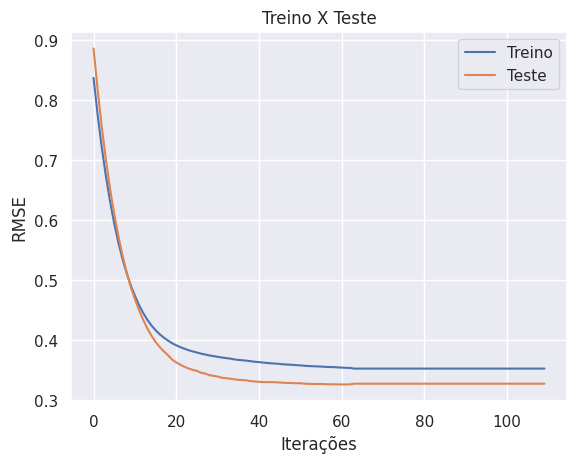

In [40]:
plt.plot(treino_rmse, label='Treino')
plt.plot(teste_rmse, label='Teste')
plt.title('Treino X Teste')
plt.xlabel('Iterações')
plt.ylabel('RMSE')
plt.legend()

* Verificando todas as métricas - R², MAE, RMSE

In [41]:
print(f'Métricas Modelo XGBoost Treino:')
print(f'R² : {metrics.r2_score(y_treino, modelo.predict(dtreino))}')
print(f'MAE : {metrics.mean_absolute_error(y_treino, modelo.predict(dtreino))}')
print(f'RMSE : {np.sqrt(metrics.mean_squared_error(y_treino, modelo.predict(dtreino)))}')

print(f'\nMétricas Modelo XGBoost Teste:')
print(f'R² : {metrics.r2_score(y_teste, modelo.predict(dteste))}')
print(f'MAE : {metrics.mean_absolute_error(y_teste, modelo.predict(dteste))}')
print(f'RMSE : {np.sqrt(metrics.mean_squared_error(y_teste, modelo.predict(dteste)))}')

Métricas Modelo XGBoost Treino:
R² : 0.8490724855092853
MAE : 0.1841600915908292
RMSE : 0.35217583290515736

Métricas Modelo XGBoost Teste:
R² : 0.8848010305890341
MAE : 0.18403942022056452
RMSE : 0.3269944739708999


# Gráfico Real X Previsto

In [42]:
y_previsto = modelo.predict(dteste)

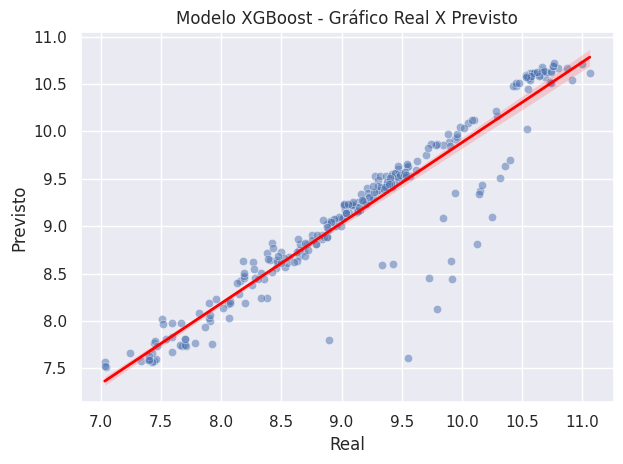

In [43]:
sns.scatterplot(x=y_teste, y=y_previsto, alpha=0.5)

sns.regplot(x=y_teste, y=y_previsto, scatter=False, color='red', line_kws={"linewidth": 2})

plt.title("Modelo XGBoost - Gráfico Real X Previsto")
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.tight_layout()
plt.show()

# Gráfico Resíduos

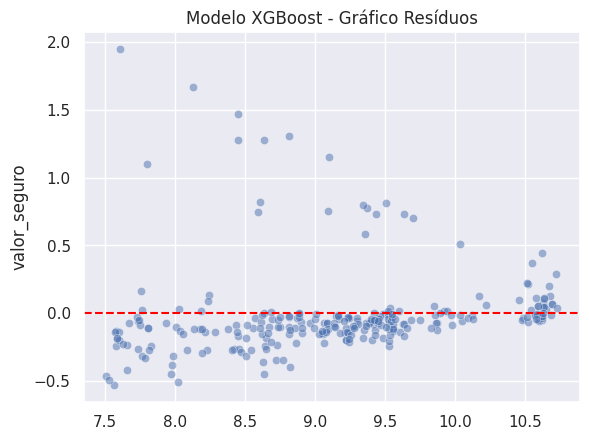

In [44]:
residuo = y_teste - y_previsto

sns.scatterplot(x=y_previsto, y=residuo, alpha=0.5)
plt.axhline(0, linestyle='--', color='red')
plt.title("Modelo XGBoost - Gráfico Resíduos")
plt.show()

## Salvando a Pipeline

In [45]:
from sklearn.pipeline import Pipeline
import joblib

In [49]:
joblib.dump(pipeline, 'preprocessamento.pkl')

['preprocessamento.pkl']

In [50]:
joblib.dump(modelo, 'modelo_xgb.pkl')

['modelo_xgb.pkl']

* Verificando as versões do projeto

In [48]:
import sklearn
import pandas
import numpy
import joblib
import xgboost
import sys

print("python:", sys.version)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)
print("xgboost:", xgboost.__version__)

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
sklearn: 1.6.1
pandas: 2.2.2
numpy: 2.0.2
joblib: 1.5.3
xgboost: 3.2.0
